In [5]:
import shutil
import os

checkpoint_folder = "/content/sample_data/train/.ipynb_checkpoints"

if os.path.exists(checkpoint_folder):
    shutil.rmtree(checkpoint_folder)
    print("Deleted .ipynb_checkpoints")
else:
    print("Folder not found")

Folder not found


In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the paths to the training and validation data
train_data_dir = '/content/dataset'
validation_data_dir = '/content/dataset'

# Set the parameters for the CNN
img_width, img_height = 150, 150
batch_size = 32
epochs = 10
num_classes = 2  # For binary classification, set this to the number of classes (e.g., 2)

# Function to create the CNN model
def create_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'] )
    return model

# Data augmentation for the training set
train_datagen = ImageDataGenerator(rescale=1.0/255,  # Normalize pixel values between 0 and 1
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

# Rescaling the validation set
validation_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading the training data
train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size=(img_width, img_height),
                                                    batch_size=batch_size,
                                                    class_mode='binary')  # For binary classification, use 'binary' instead

# Loading the validation data
validation_generator = validation_datagen.flow_from_directory(validation_data_dir,
                                                              target_size=(img_width, img_height),
                                                              batch_size=batch_size,
                                                              class_mode='binary')  # For binary classification, use 'binary' instead



Found 10 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


In [9]:
# import os
# print(os.listdir('//content/dataset))
['female','male','.ipynb_checkpoints']

['female', 'male', '.ipynb_checkpoints']

In [10]:
# Creating the CNN model
model = create_model()

# Train the model
model.fit(train_generator,
          steps_per_epoch=len(train_generator),
          epochs=epochs,
          validation_data=validation_generator,
          validation_steps=len(validation_generator))

# Save the model for future use
model.save('binary_image_classifier.h5')

print("Training and validation completed!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6368
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6546 - val_accuracy: 0.5000 - val_loss: 1.6593
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 1.5538 - val_accuracy: 0.7000 - val_loss: 0.5525
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 0.5802 - val_accuracy: 0.5000 - val_loss: 0.7092
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7437 - val_accuracy: 0.5000 - val_loss: 0.6074
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6158 - val_accuracy: 0.8000 - val_loss: 0.5135
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8000 - loss: 0.5278 - val_accuracy: 0.9000 - val_loss: 0.4657
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8000 - loss: 0.5031 - val_accuracy: 0.8000 - val_loss: 0.4222
Epoch 9/10
1/1 ━

Training and validation completed!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


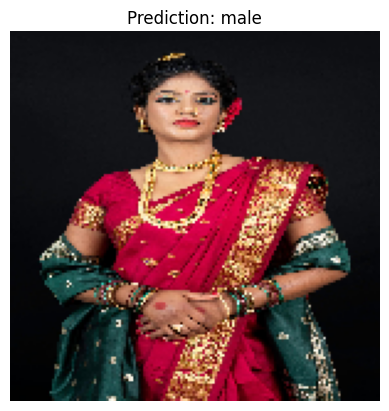

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the trained model
model = load_model('binary_image_classifier.h5')  # Corrected: Load the .h5 model file

# Load and preprocess the test image
img_path = '/content/test/female1.jpg'  # Replace this with the actual path to the test image
img = image.load_img(img_path, target_size=(150, 150))  # Assuming the same target size as used during training
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x /= 255.0  # Normalize pixel values between 0 and 1, just like during training

# Perform inference
predictions = model.predict(x)

# Check the prediction result
pred = predictions[0][0]

if pred >= 0.5:
    result = "female"      # Adjusted based on context that '/content/TEST/female.jpg' is a female
else:
    result = "male"       # Assuming 0.5 is the threshold for binary classification

# Display the image and the result
plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis('off')
plt.show()

In [12]:
print(predictions)
print(predictions.shape)

[[0.03896903]]
(1, 1)
